# zeitreihe_menden

Collab für uns alle

1. Setup und Daten laden

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [4]:

amazon = pd.read_csv("data/raw/amazon_sales_dataset.csv", low_memory=False, sep=";")
apple = pd.read_csv("data/raw/apple_stock.csv")
weather = pd.read_csv("data/raw/weather_ts.csv")

datasets = {
    "Amazon Sales": amazon,
    "Apple Stock": apple,
    "Weather": weather
}

for name, df in datasets.items():
    print(name)
    print(df.shape)
    display(df.head())
    print("=" * 150)


Amazon Sales
(50000, 13)


,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


Apple Stock
(2598, 6)


,Price,Close,High,Low,Open,Volume
0,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
1,Date,NaN,NaN,NaN,NaN,NaN
2,2016-01-04,23.730947494506836,23.735453620243067,22.976332980529655,23.113740599566555,270597600
3,2016-01-05,23.136259078979492,23.84356937042439,23.06868268061348,23.82104390430239,223164000
4,2016-01-06,22.68349266052246,23.059675038056618,22.496529721573108,22.651956660286036,273829600


Weather
(420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


### Stil setzen

In [7]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

## Amazon Sales plt

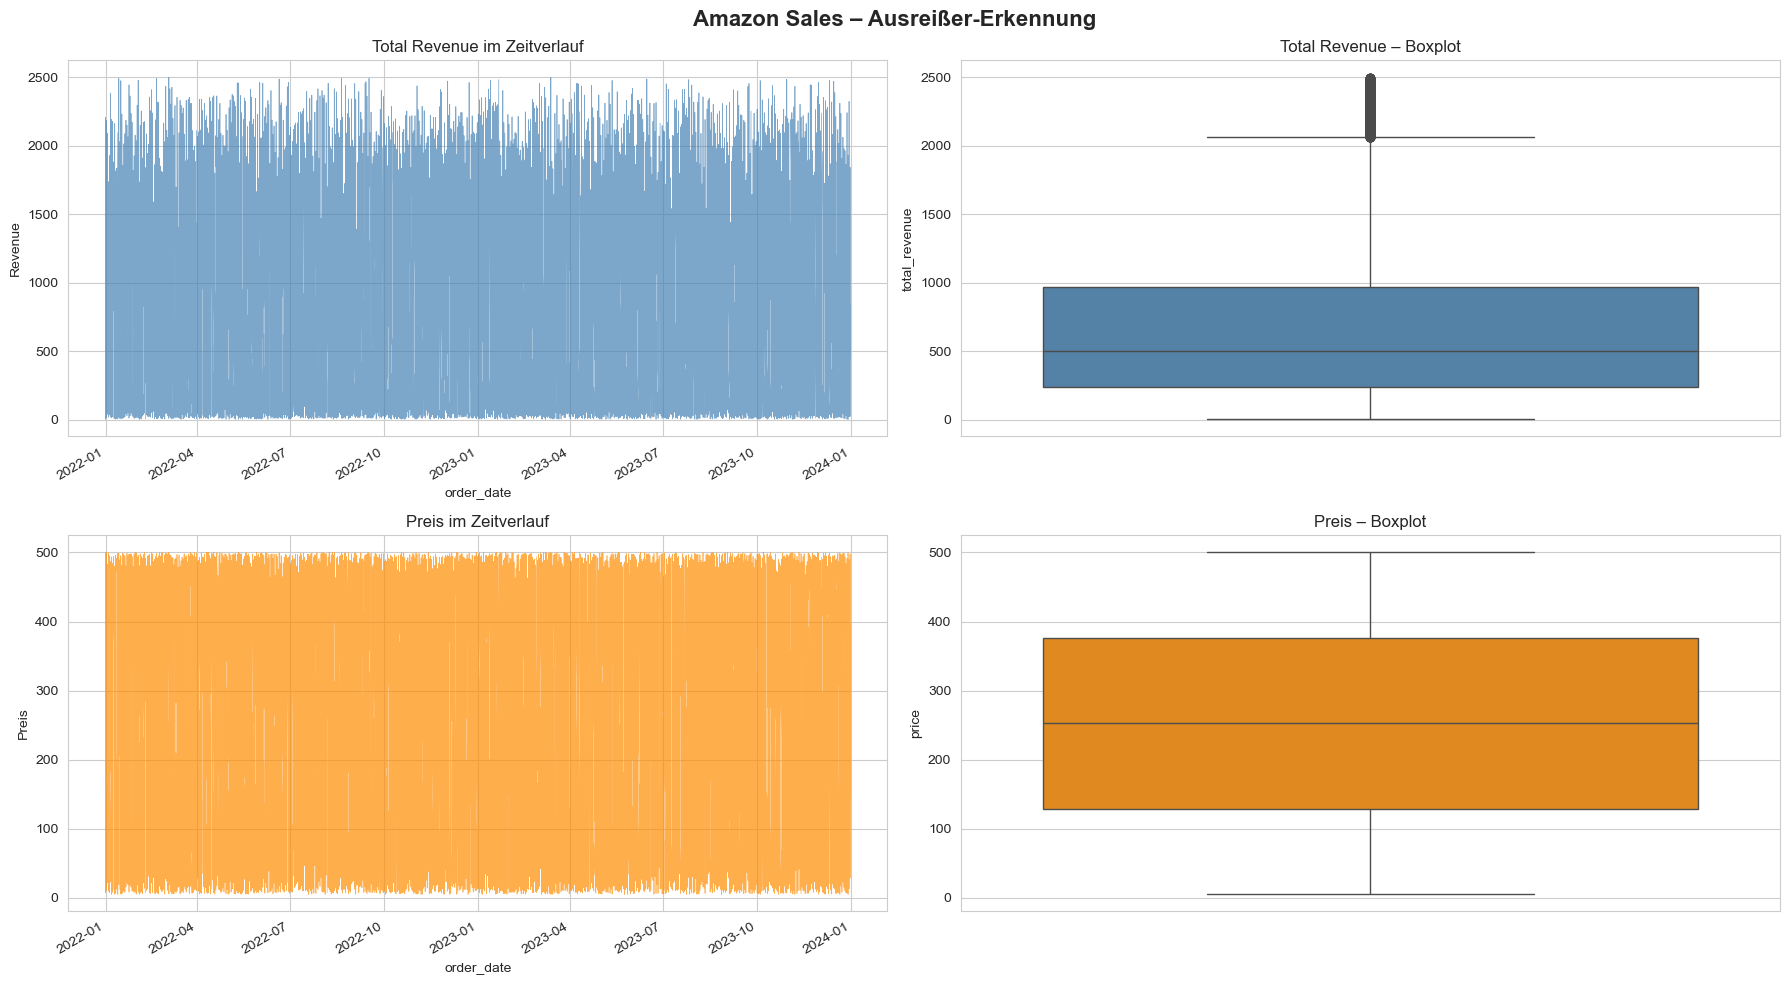

In [14]:
# --- Amazon Sales: Ausreißer-Erkennung ---
df = datasets["Amazon Sales"]
df["order_date"] = pd.to_datetime(df["order_date"])
df = df.sort_values("order_date")

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle("Amazon Sales – Ausreißer-Erkennung", fontsize=16, weight="bold")

# Liniendiagramm: Total Revenue über Zeit
df.plot(x="order_date", y="total_revenue", ax=axes[0, 0], 
        color="steelblue", linewidth=0.5, alpha=0.7, legend=False)
axes[0, 0].set_title("Total Revenue im Zeitverlauf")
axes[0, 0].set_ylabel("Revenue")

# Boxplot: Total Revenue
sns.boxplot(y=df["total_revenue"], ax=axes[0, 1], color="steelblue")
axes[0, 1].set_title("Total Revenue – Boxplot")

# Liniendiagramm: Price über Zeit
df.plot(x="order_date", y="price", ax=axes[1, 0], 
        color="darkorange", linewidth=0.5, alpha=0.7, legend=False)
axes[1, 0].set_title("Preis im Zeitverlauf")
axes[1, 0].set_ylabel("Preis")

# Boxplot: Price
sns.boxplot(y=df["price"], ax=axes[1, 1], color="darkorange")
axes[1, 1].set_title("Preis – Boxplot")

plt.tight_layout()
plt.show()

### Apple Stock plt

In [15]:
# --- Apple Stock: Ausreißer-Erkennung ---
df = datasets["Apple Stock"]
df.columns = df.iloc[0]
df = df.drop([0, 1]).reset_index(drop=True)
df = df.rename(columns={"Price": "Date"})
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle("Apple Stock – Ausreißer-Erkennung", fontsize=16, weight="bold")

# Liniendiagramm: Close im Zeitverlauf
df["Close"].plot(ax=axes[0, 0], color="navy", linewidth=0.8)
axes[0, 0].set_title("AAPL Close – Zeitverlauf")
axes[0, 0].set_ylabel("Preis (USD)")

# Boxplot: Close
sns.boxplot(y=df["Close"], ax=axes[0, 1], color="navy")
axes[0, 1].set_title("AAPL Close – Boxplot")

# Liniendiagramm: Volume im Zeitverlauf
df["Volume"].plot(ax=axes[1, 0], color="darkgreen", linewidth=0.8)
axes[1, 0].set_title("AAPL Volume – Zeitverlauf")
axes[1, 0].set_ylabel("Volumen")

# Boxplot: Volume
sns.boxplot(y=df["Volume"], ax=axes[1, 1], color="darkgreen")
axes[1, 1].set_title("AAPL Volume – Boxplot")

plt.tight_layout()
plt.show()

KeyError: 'Date'

### Weather plt

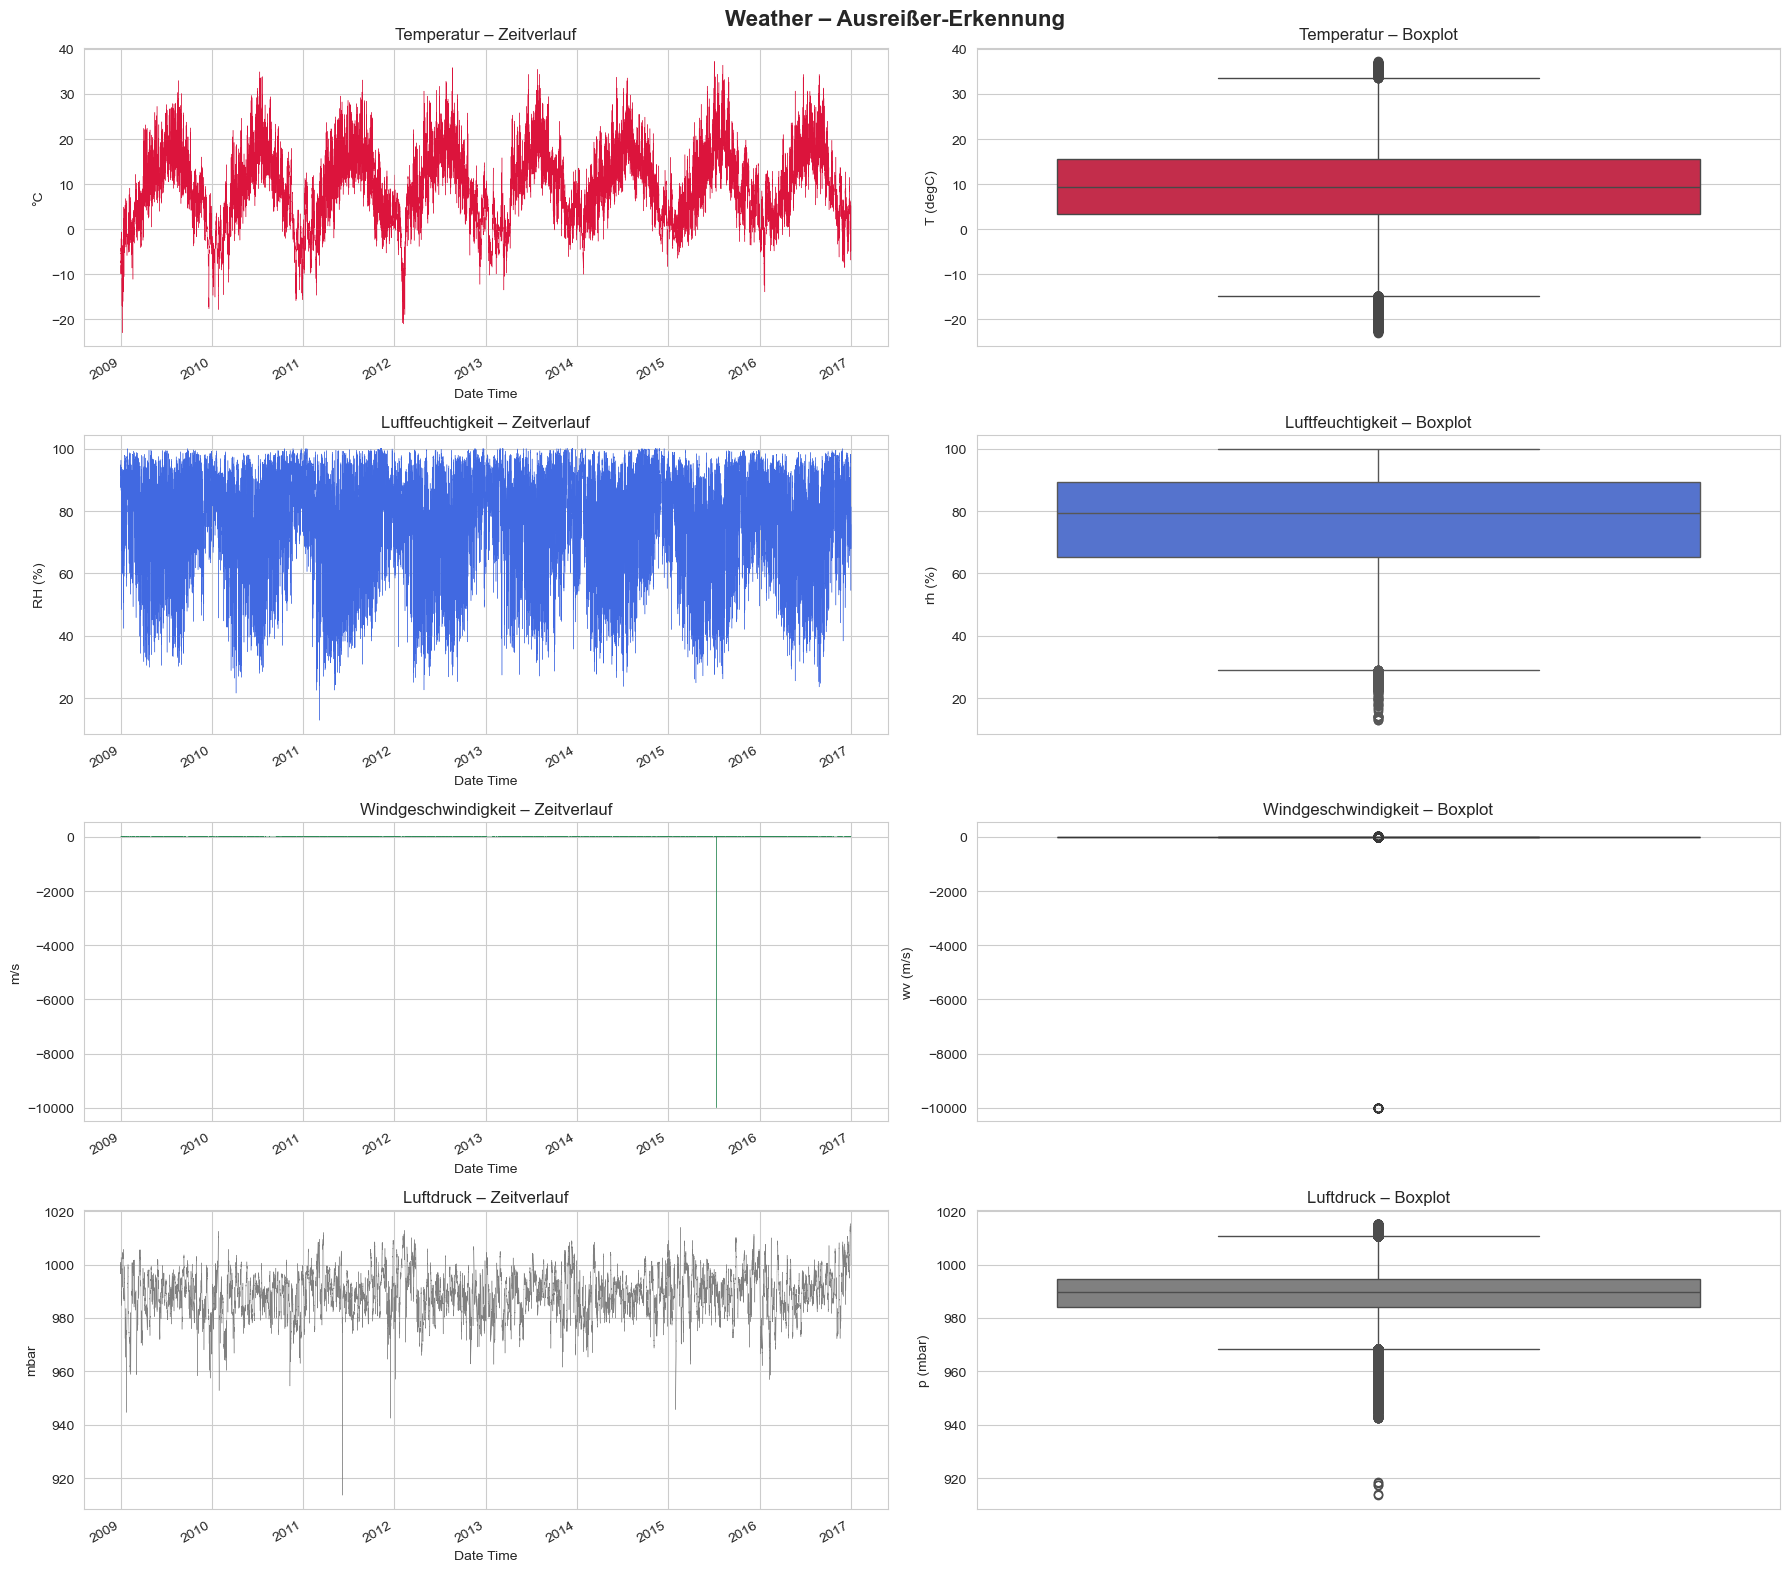

In [16]:
# --- Weather: Ausreißer-Erkennung ---
df = datasets["Weather"]
df["Date Time"] = pd.to_datetime(df["Date Time"], format="%d.%m.%Y %H:%M:%S")
df = df.set_index("Date Time")

fig, axes = plt.subplots(4, 2, figsize=(18, 16))
fig.suptitle("Weather – Ausreißer-Erkennung", fontsize=16, weight="bold")

# Temperatur: Liniendiagramm + Boxplot
df["T (degC)"].plot(ax=axes[0, 0], color="crimson", linewidth=0.3)
axes[0, 0].set_title("Temperatur – Zeitverlauf")
axes[0, 0].set_ylabel("°C")

sns.boxplot(y=df["T (degC)"], ax=axes[0, 1], color="crimson")
axes[0, 1].set_title("Temperatur – Boxplot")

# Luftfeuchtigkeit: Liniendiagramm + Boxplot
df["rh (%)"].plot(ax=axes[1, 0], color="royalblue", linewidth=0.3)
axes[1, 0].set_title("Luftfeuchtigkeit – Zeitverlauf")
axes[1, 0].set_ylabel("RH (%)")

sns.boxplot(y=df["rh (%)"], ax=axes[1, 1], color="royalblue")
axes[1, 1].set_title("Luftfeuchtigkeit – Boxplot")

# Windgeschwindigkeit: Liniendiagramm + Boxplot
df["wv (m/s)"].plot(ax=axes[2, 0], color="seagreen", linewidth=0.3)
axes[2, 0].set_title("Windgeschwindigkeit – Zeitverlauf")
axes[2, 0].set_ylabel("m/s")

sns.boxplot(y=df["wv (m/s)"], ax=axes[2, 1], color="seagreen")
axes[2, 1].set_title("Windgeschwindigkeit – Boxplot")

# Luftdruck: Liniendiagramm + Boxplot
df["p (mbar)"].plot(ax=axes[3, 0], color="gray", linewidth=0.3)
axes[3, 0].set_title("Luftdruck – Zeitverlauf")
axes[3, 0].set_ylabel("mbar")

sns.boxplot(y=df["p (mbar)"], ax=axes[3, 1], color="gray")
axes[3, 1].set_title("Luftdruck – Boxplot")

plt.tight_layout()
plt.show()

In [8]:
# ─────────────────────────────────────────────
# 1. DATEN LADEN
# ─────────────────────────────────────────────
 
amazon  = pd.read_csv("data/raw/amazon_sales_dataset.csv", low_memory=False, sep=";")
apple   = pd.read_csv("data/raw/apple_stock.csv", header=0, skiprows=[1, 2])
weather = pd.read_csv("data/raw/weather_ts.csv")
 
 
# ─────────────────────────────────────────────
# HILFSFUNKTION: Outlier-Entfernung per IQR
# (Menden Skript, Folie 48: Outlier Detection)
# Ein Datenpunkt gilt als Ausreißer, wenn er
# größer als das 1,5-fache der IQR ist.
# ─────────────────────────────────────────────
 
def remove_outliers_iqr(df, columns):
    """Entfernt Ausreißer anhand der IQR-Methode (1.5 * IQR)."""
    mask = pd.Series(True, index=df.index)
    for col in columns:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        mask &= (df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)
    return df[mask]
 
 
# ─────────────────────────────────────────────
# 2. AMAZON – Sales Daten bereinigen
# ─────────────────────────────────────────────
 
amazon["order_date"] = pd.to_datetime(amazon["order_date"])
amazon = amazon.set_index("order_date").sort_index()
amazon = amazon.drop_duplicates()
amazon = amazon.dropna()
amazon = remove_outliers_iqr(amazon, ["total_revenue", "price"])
 
print("Amazon bereinigt:", amazon.shape)
 
 
# ─────────────────────────────────────────────
# 3. APPLE – Aktienkurse bereinigen
# ─────────────────────────────────────────────
 
apple = apple.rename(columns={"Price": "Date"})
apple["Date"] = pd.to_datetime(apple["Date"])
apple = apple.set_index("Date").sort_index()
for col in apple.columns:
    apple[col] = pd.to_numeric(apple[col], errors="coerce")
apple = apple.drop_duplicates()
apple = apple.dropna()
apple = remove_outliers_iqr(apple, ["Close"])
 
print("Apple bereinigt:", apple.shape)
 
 
# ─────────────────────────────────────────────
# 4. WEATHER – Wetterdaten bereinigen
# ─────────────────────────────────────────────
 
weather["Date Time"] = pd.to_datetime(weather["Date Time"], dayfirst=True)
weather = weather.set_index("Date Time").sort_index()
weather = weather.drop_duplicates()
weather = weather.dropna()
weather = weather[weather["wv (m/s)"] >= 0]
weather = weather[weather["max. wv (m/s)"] >= 0]
weather = remove_outliers_iqr(weather, ["T (degC)"])
 
print("Weather bereinigt:", weather.shape)
 
 
# ─────────────────────────────────────────────
# 5. WACHSTUMSRATEN berechnen
# (Menden Skript, Folie 15/16: Wachstumsraten)
# gt = (xt - xt-1) / xt-1
# ─────────────────────────────────────────────
 
amazon_daily = amazon["total_revenue"].resample("D").sum()
amazon["revenue_growth"] = amazon_daily.pct_change()
 
apple["close_growth"] = apple["Close"].pct_change()
 
weather["temp_diff"] = weather["T (degC)"].diff()
 
 
# ─────────────────────────────────────────────
# 6. ÜBERBLICK
# ─────────────────────────────────────────────
 
datasets_clean = {
    "Amazon Sales": amazon,
    "Apple Stock":  apple,
    "Weather":      weather,
}
 
for name, df in datasets_clean.items():
    print(f"\n{'─' * 45}")
    print(f" {name}")
    print(f"   Shape:       {df.shape}")
    print(f"   Zeitraum:    {df.index.min()}  →  {df.index.max()}")
    print(f"   NaN gesamt:  {df.isnull().sum().sum()}")
    print(f"   Dtype Index: {df.index.dtype}")

Amazon bereinigt: (49248, 12)
Apple bereinigt: (2596, 5)
Weather bereinigt: (418665, 14)

─────────────────────────────────────────────
 Amazon Sales
   Shape:       (49248, 13)
   Zeitraum:    2022-01-01 00:00:00  →  2023-12-31 00:00:00
   NaN gesamt:  66
   Dtype Index: datetime64[ns]

─────────────────────────────────────────────
 Apple Stock
   Shape:       (2596, 6)
   Zeitraum:    2016-01-04 00:00:00  →  2026-04-30 00:00:00
   NaN gesamt:  1
   Dtype Index: datetime64[ns]

─────────────────────────────────────────────
 Weather
   Shape:       (418665, 15)
   Zeitraum:    2009-01-01 00:10:00  →  2017-01-01 00:00:00
   NaN gesamt:  1
   Dtype Index: datetime64[ns]
